In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import joblib
import os

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:559: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/4 | Train Loss: 0.4852 | Val Loss: 0.3691
Epoch 2/4 | Train Loss: 0.3283 | Val Loss: 0.3488
Epoch 3/4 | Train Loss: 0.2782 | Val Loss: 0.3191
Epoch 4/4 | Train Loss: 0.2354 | Val Loss: 0.3569


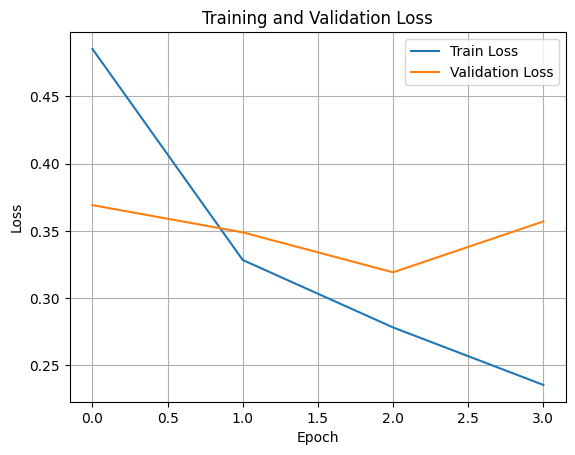

In [ ]:

# ==== 1. Setup ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "microsoft/deberta-v3-base"

# ==== 2. Load and Encode Data ====
df = pd.read_csv("cyberbullying_tweets.csv")[["tweet_text", "cyberbullying_type"]].dropna()
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["cyberbullying_type"])
num_labels = len(label_encoder.classes_)
joblib.dump(label_encoder, "label_encoder.pkl")

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["tweet_text"].tolist(), df["label"].tolist(), test_size=0.2, stratify=df["label"], random_state=42
)

# ==== 3. Tokenizer and Dataset ====
tokenizer = AutoTokenizer.from_pretrained(model_name)

class BullyDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_length)
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = BullyDataset(train_texts, train_labels, tokenizer)
test_dataset = BullyDataset(test_texts, test_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

# ==== 4. Model, Optimizer, Loss ====
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
criterion = torch.nn.CrossEntropyLoss()

# ==== 5. Training Loop ====
train_losses, test_losses = [], []
epochs = 4

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        running_loss += loss.item()
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            val_loss += outputs.loss.item()
    avg_val_loss = val_loss / len(test_loader)
    test_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

# ==== 6. Save Model ====
os.makedirs("deberta_cyberbullying_model", exist_ok=True)
model.save_pretrained("deberta_cyberbullying_model")
tokenizer.save_pretrained("deberta_cyberbullying_model")

# ==== 7. Plot Loss ====
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Collect all predictions and true labels
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        labels = batch["labels"].cpu().numpy()
        inputs = {k: v.to(device) for k, v in batch.items() if k != "labels"}
        outputs = model(**inputs)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

# Print classification report
class_names = label_encoder.classes_
report = classification_report(all_labels, all_preds, target_names=class_names)
print(report)


                     precision    recall  f1-score   support

                age       0.99      0.98      0.99      1598
          ethnicity       0.98      0.97      0.98      1592
             gender       0.86      0.92      0.89      1595
  not_cyberbullying       0.74      0.61      0.67      1589
other_cyberbullying       0.71      0.79      0.75      1565
           religion       0.96      0.96      0.96      1600

           accuracy                           0.87      9539
          macro avg       0.87      0.87      0.87      9539
       weighted avg       0.87      0.87      0.87      9539



In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import joblib

# --- 1. Load model, tokenizer, and label encoder ---
model_dir = "deberta_cyberbullying_model"
tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(model_dir)
label_encoder = joblib.load("label_encoder.pkl")

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# --- 2. Your test string ---
text = "all chinese people eat dogs"

# --- 3. Tokenize and predict ---
inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)
    pred_label_idx = torch.argmax(probs, dim=1).item()
    pred_class = label_encoder.inverse_transform([pred_label_idx])[0]

print(f"Predicted class index: {pred_label_idx}")
print(f"Predicted class name: {pred_class}")
print(f"Class probabilities: {probs.cpu().numpy()}")


Predicted class index: 5
Predicted class name: religion
Class probabilities: [[1.9221392e-04 3.6850679e-04 6.6238012e-05 2.6711568e-04 1.2158597e-05
  9.9909377e-01]]
